In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


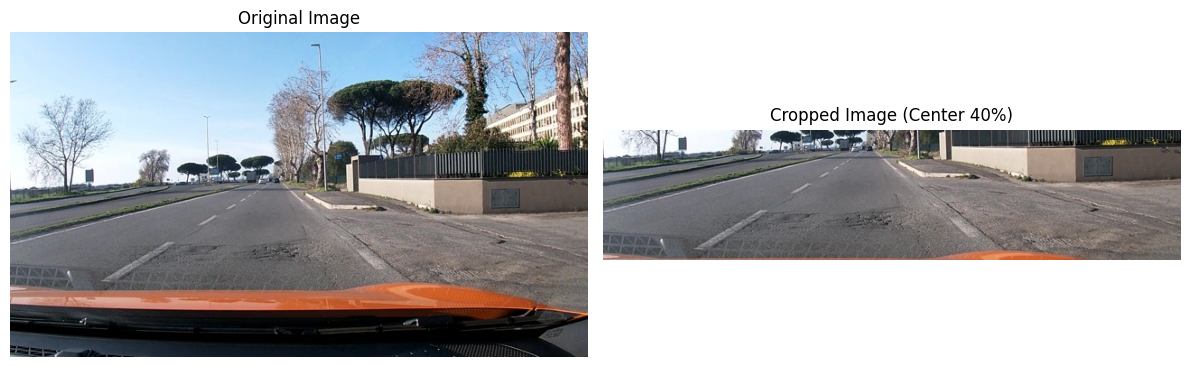

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/프로젝트 4조/Road/data/images/vlcsnap-00063.jpg'

img = cv2.imread(image_path)

if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    height, width, _ = img_rgb.shape

    y_start = int(height * 0.4)
    y_end = int(height * 0.8)

    cropped_img = img_rgb[y_start : y_end, 0 : width]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cropped_img)
    plt.title('Cropped Image (Center 40%)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

이미지 크롭하는 과정

In [ ]:
import os
import cv2

input_img_dir = '/content/drive/MyDrive/프로젝트 4조/Road/data/images'
input_lbl_dir = '/content/drive/MyDrive/프로젝트 4조/Road/data/labels-YOLO'

output_img_dir = '/content/drive/MyDrive/프로젝트 4조/Road/data/images_cropped'
output_lbl_dir = '/content/drive/MyDrive/프로젝트 4조/Road/data/labels_cropped'

os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_lbl_dir, exist_ok=True)

image_files = [f for f in os.listdir(input_img_dir) if f.endswith(('.jpg', '.png'))]
total_files = len(image_files)

crop_top_ratio = 0.4
crop_bottom_ratio = 0.8

print(f"총 {total_files}개의 데이터 변환을 시작합니다. (중앙 40% 노면 집중 크롭 및 덮어쓰기)")

for idx, img_file in enumerate(image_files):
    img_path = os.path.join(input_img_dir, img_file)
    img = cv2.imread(img_path)

    if img is None: continue

    h, w, _ = img.shape
    y_start = int(h * crop_top_ratio)
    y_end = int(h * crop_bottom_ratio)

    cropped_img = img[y_start:y_end, 0:w]

    out_img_path = os.path.join(output_img_dir, img_file)
    cv2.imwrite(out_img_path, cropped_img)

    txt_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')
    txt_path = os.path.join(input_lbl_dir, txt_file)
    out_txt_path = os.path.join(output_lbl_dir, txt_file)

    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5: continue

            class_id, x_center, y_center, bbox_w, bbox_h = map(float, parts[:5])

            y_min = y_center - (bbox_h / 2)
            y_max = y_center + (bbox_h / 2)

            if y_max <= crop_top_ratio or y_min >= crop_bottom_ratio:
                continue

            y_min_new = max(crop_top_ratio, y_min)
            y_max_new = min(crop_bottom_ratio, y_max)

            new_h_ratio = crop_bottom_ratio - crop_top_ratio
            new_y_min_rel = (y_min_new - crop_top_ratio) / new_h_ratio
            new_y_max_rel = (y_max_new - crop_top_ratio) / new_h_ratio

            new_y_center = (new_y_min_rel + new_y_max_rel) / 2.0
            new_bbox_h = new_y_max_rel - new_y_min_rel

            new_lines.append(f"{int(class_id)} {x_center:.6f} {new_y_center:.6f} {bbox_w:.6f} {new_bbox_h:.6f}\n")

        with open(out_txt_path, 'w') as f:
            f.writelines(new_lines)

    if (idx + 1) % 100 == 0:
        print(f"진행 중... ({idx + 1}/{total_files})")

print(" 가설 2.0 변환 및 라벨 수정이 완벽하게 완료되었습니다!")

총 2009개의 데이터 변환을 시작합니다. (중앙 40% 노면 집중 크롭 및 덮어쓰기)
진행 중... (100/2009)
진행 중... (200/2009)
진행 중... (300/2009)
진행 중... (400/2009)
진행 중... (500/2009)
진행 중... (600/2009)
진행 중... (700/2009)
진행 중... (800/2009)
진행 중... (900/2009)
진행 중... (1000/2009)
진행 중... (1100/2009)
진행 중... (1200/2009)
진행 중... (1300/2009)
진행 중... (1400/2009)
진행 중... (1500/2009)
진행 중... (1600/2009)
진행 중... (1700/2009)
진행 중... (1800/2009)
진행 중... (1900/2009)
진행 중... (2000/2009)
🎉 가설 2.0 변환 및 라벨 수정이 완벽하게 완료되었습니다!


In [ ]:
import os
check_path = '/content/drive/MyDrive/프로젝트 4조/Road/data/images_cropped'

if os.path.exists(check_path):
    file_count = len(os.listdir(check_path))
    print(f"현재 저장된 이미지 개수: {file_count}개")
else:
    print("반영 X")

✅ 폴더가 존재합니다! 현재 저장된 이미지 개수: 2009개


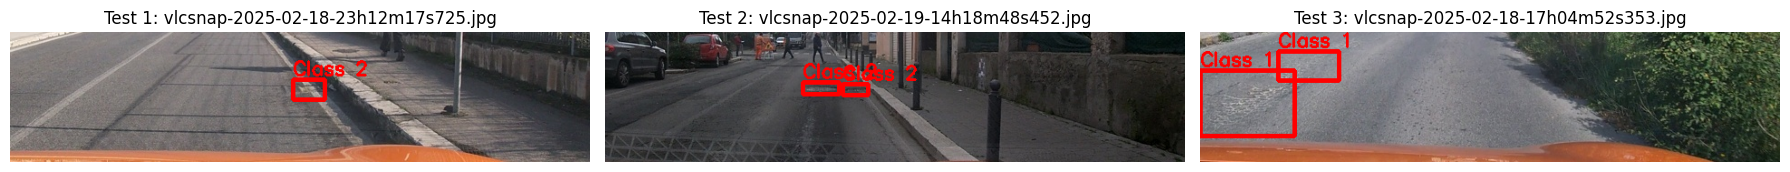

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

img_dir = '/content/drive/MyDrive/프로젝트 4조/Road/data/images_cropped'
lbl_dir = '/content/drive/MyDrive/프로젝트 4조/Road/data/labels_cropped'

all_images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
sample_images = random.sample(all_images, 3)

plt.figure(figsize=(18, 6))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(img_dir, img_name)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    txt_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
    txt_path = os.path.join(lbl_dir, txt_name)

    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5: continue

                class_id = int(float(parts[0]))
                x_center, y_center, bbox_w, bbox_h = map(float, parts[1:5])

                x_min = int((x_center - bbox_w / 2) * w)
                y_min = int((y_center - bbox_h / 2) * h)
                x_max = int((x_center + bbox_w / 2) * w)
                y_max = int((y_center + bbox_h / 2) * h)

                cv2.rectangle(img_rgb, (x_min, y_min), (x_max, y_max), (255, 0, 0), 3)
                cv2.putText(img_rgb, f'Class {class_id}', (x_min, y_min - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Test {i+1}: {img_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
import random

src_img_dir = '/content/drive/MyDrive/프로젝트 4조/Road/data/images_cropped'
src_lbl_dir = '/content/drive/MyDrive/프로젝트 4조/Road/data/labels_cropped'

base_dir = '/content/drive/MyDrive/프로젝트 4조/Road/dataset'

train_img_dir = os.path.join(base_dir, 'images/train')
val_img_dir = os.path.join(base_dir, 'images/val')
train_lbl_dir = os.path.join(base_dir, 'labels/train')
val_lbl_dir = os.path.join(base_dir, 'labels/val')

for d in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
    os.makedirs(d, exist_ok=True)

image_files = [f for f in os.listdir(src_img_dir) if f.endswith(('.jpg', '.png'))]
random.seed(42)
random.shuffle(image_files)

split_index = int(len(image_files) * 0.8)
train_files = image_files[:split_index]
val_files = image_files[split_index:]

def copy_dataset(file_list, target_img_dir, target_lbl_dir, dataset_type):
    print(f"\n {dataset_type} 데이터셋 복사 시작... (총 {len(file_list)}장)")
    for idx, img_name in enumerate(file_list):
        src_img_path = os.path.join(src_img_dir, img_name)
        dst_img_path = os.path.join(target_img_dir, img_name)
        shutil.copy(src_img_path, dst_img_path)

        txt_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
        src_txt_path = os.path.join(src_lbl_dir, txt_name)
        dst_txt_path = os.path.join(target_lbl_dir, txt_name)

        if os.path.exists(src_txt_path):
            shutil.copy(src_txt_path, dst_txt_path)

        if (idx + 1) % 200 == 0:
            print(f"[{dataset_type}] 진행 중... ({idx + 1}/{len(file_list)})")

print(f"총 {len(image_files)}장의 데이터를 Train(8) : Val(2) 로 분할합니다.")
copy_dataset(train_files, train_img_dir, train_lbl_dir, "Train")
copy_dataset(val_files, val_img_dir, val_lbl_dir, "Val")

print("\n dataset 폴더 확인")

총 2009장의 데이터를 Train(8) : Val(2) 로 분할합니다.

🚀 Train 데이터셋 복사 시작... (총 1607장)
[Train] 진행 중... (200/1607)
[Train] 진행 중... (400/1607)
[Train] 진행 중... (600/1607)
[Train] 진행 중... (800/1607)
[Train] 진행 중... (1000/1607)
[Train] 진행 중... (1200/1607)
[Train] 진행 중... (1400/1607)
[Train] 진행 중... (1600/1607)

🚀 Val 데이터셋 복사 시작... (총 402장)
[Val] 진행 중... (200/402)
[Val] 진행 중... (400/402)

🎉 모든 분할 및 폴더 정리가 완벽하게 끝났습니다! 구글 드라이브 'dataset' 폴더를 확인해 보세요.


In [ ]:
import yaml

data = {
    'path': '/content/drive/MyDrive/프로젝트 4조/Road/dataset',
    'train': 'images/train',
    'val': 'images/val',

    'nc': 3,
    'names': ['Pothole', 'Crack', 'Manhole']
}

yaml_path = '/content/drive/MyDrive/프로젝트 4조/Road/dataset/data.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("data.yaml 파일 생성 완료")

data.yaml 파일 생성 완료
